<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Read World bank CSV

In [38]:
df = pd.read_csv("WorldBank.csv")

In [39]:
df.head(5)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,...,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,...,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 65 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    1440 non-null   object 
 1   Country Code    1440 non-null   object 
 2   Indicator Name  1440 non-null   object 
 3   Indicator Code  1440 non-null   object 
 4   1960            277 non-null    float64
 5   1961            315 non-null    float64
 6   1962            326 non-null    float64
 7   1963            328 non-null    float64
 8   1964            331 non-null    float64
 9   1965            337 non-null    float64
 10  1966            331 non-null    float64
 11  1967            338 non-null    float64
 12  1968            336 non-null    float64
 13  1969            344 non-null    float64
 14  1970            426 non-null    float64
 15  1971            514 non-null    float64
 16  1972            478 non-null    float64
 17  1973            484 non-null    f

# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [41]:
data = df[df['Indicator Name'] == 'Population ages 15-64 (% of total population)']
data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [42]:
X = np.arange(1960,2020).reshape(-1,1)
y = data.values[0][4:-1].reshape(-1,1)
X

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019]])

In [43]:
y

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

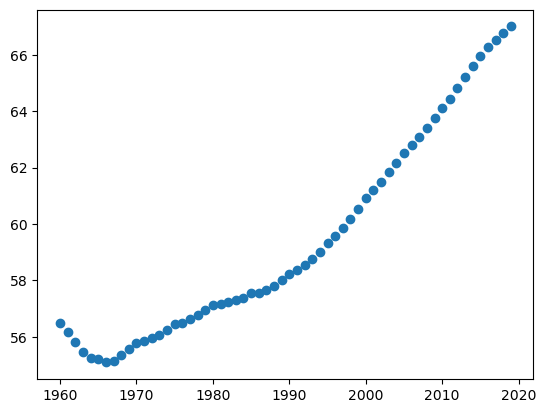

In [44]:
plt.scatter(X,y)
plt.show()

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [45]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()

In [46]:
X_scale = sc_X.fit_transform(X)
y_scale = sc_y.fit_transform(y)

# Splitting the dataset into the Training set and Test set

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_scale,y_scale)

# Fitting SVR on 3 Different Kernel on dataset

In [48]:
from sklearn.svm import SVR
model_liner = SVR(kernel='linear')
model_poly = SVR(kernel='poly',degree=3)
model_rbf = SVR(kernel='rbf')

In [49]:
model_liner.fit(X_train,y_train.flatten())

SVR(kernel='linear')

In [50]:
model_poly.fit(X_train,y_train.flatten())

SVR(kernel='poly')

In [51]:
model_rbf.fit(X_train,y_train.flatten())

SVR()

In [52]:
model_liner.score(X_train,y_train.flatten())

0.9245572888999699

In [53]:
model_poly.score(X_train,y_train.flatten())

0.6895142227644498

In [54]:
model_rbf.score(X_train,y_train.flatten())

0.994872361854116

# Predict the x_test using 3 Kernel

In [55]:
y_actule = sc_y.inverse_transform(y_test)
y_pred_liner = model_liner.predict(y_test)
y_pred_poly = model_poly.predict(y_test)
y_pred_rbf = model_rbf.predict(y_test)

In [56]:
y_actule

array([[55.57014408],
       [56.17753236],
       [58.01501187],
       [61.18898716],
       [65.5959799 ],
       [59.012126  ],
       [65.94416405],
       [66.7667425 ],
       [55.46166361],
       [57.55350984],
       [55.24893881],
       [64.429404  ],
       [55.15534672],
       [58.37403848],
       [58.75605047]])

In [57]:
y_pred_liner

array([-1.08748481, -0.92332123, -0.42669128,  0.43116383,  1.62227621,
       -0.15719345,  1.71638266,  1.93870737, -1.11680467, -0.55142504,
       -1.17429946,  1.30697662, -1.19959533, -0.32965435, -0.22640498])

In [58]:
y_pred_poly

array([-0.81771154, -0.54790819, -0.17906668, -0.0824747 ,  2.59013475,
       -0.14679629,  3.0803669 ,  4.46357501, -0.87594739, -0.22317224,
       -0.99972715,  1.31234228, -1.05834556, -0.15971479, -0.14952524])

In [59]:
y_pred_rbf

array([-1.0414066 , -0.95069817, -0.57303096,  0.21328632,  1.89489505,
       -0.37001118,  1.87803364,  1.70431717, -1.05322767, -0.66956647,
       -1.07170379,  1.68547639, -1.07771961, -0.49963351, -0.42230137])

# Visualising the  results

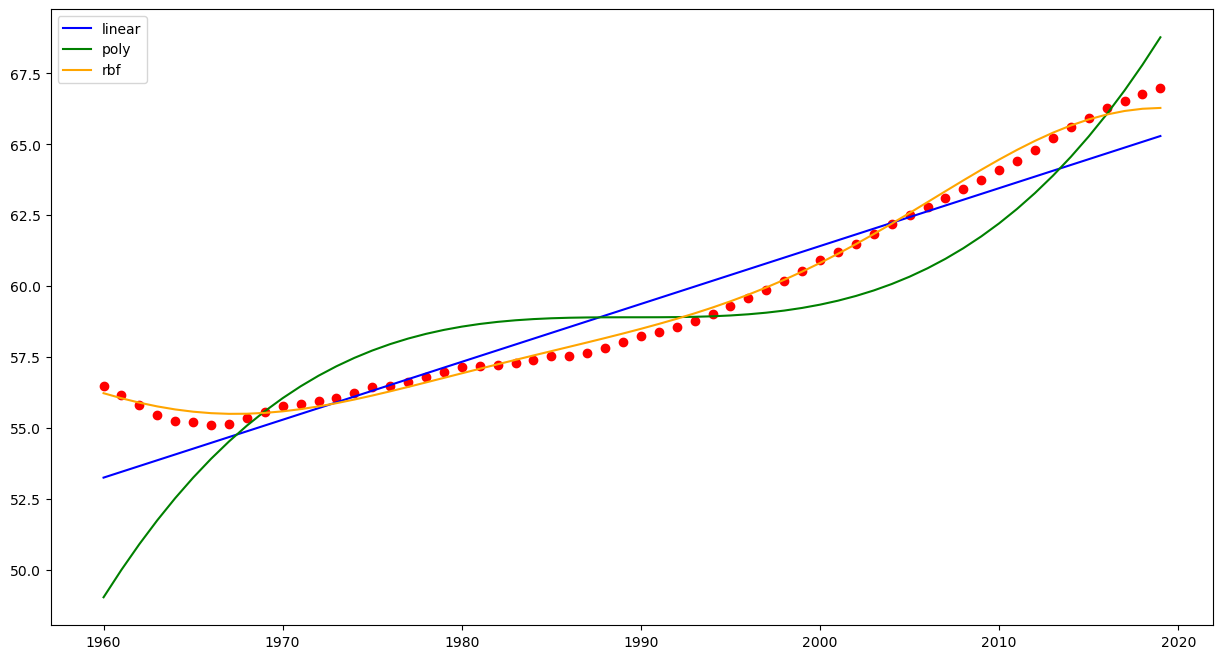

In [63]:
plt.figure(figsize=(15,8))
plt.scatter(X,y,c='r')
plt.plot(X,sc_y.inverse_transform(model_liner.predict(X_scale).reshape(-1,1)),label="linear",color="blue")
plt.plot(X,sc_y.inverse_transform(model_poly.predict(X_scale).reshape(-1,1)),label="poly",color="green")
plt.plot(X,sc_y.inverse_transform(model_rbf.predict(X_scale).reshape(-1,1)),label="rbf",color="orange")
plt.legend()
plt.show()

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

In [69]:
year_to_predict = 2025
year_to_predict_scaled = sc_X.transform(np.array([[year_to_predict]]))
predicted_value_scaled = model_rbf.predict(year_to_predict_scaled)
predicted_value_original = sc_y.inverse_transform(predicted_value_scaled.reshape(-1,1))

In [70]:
predicted_value_original

array([[65.50609726]])